In [1]:
#pip install mysql-connector-python pandas

   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
    --------------------------------------- 0.3/16.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.5 MB 1.9 MB/s eta 0:00:09
   -- ------------------------------------- 1.0/16.5 MB 2.0 MB/s eta 0:00:08
   --- ------------------------------------ 1.3/16.5 MB 1.9 MB/s eta 0:00:08
   ---- ----------------------------------- 1.8/16.5 MB 1.9 MB/s eta 0:00:08
   ----- ---------------------------------- 2.1/16.5 MB 1.9 MB/s eta 0:00:08
   ----- ---------------------------------- 2.4/16.5 MB 1.8 MB/s eta 0:00:09
   ------ --------------------------------- 2.9/16.5 MB 1.8 MB/s eta 0:00:08
   -------- ------------------------------- 3.4/16.5 MB 1.8 MB/s eta 0:00:08
   -------- ------------------------------- 3.7/16.5 MB 1.8 MB/s eta 0:00:08
   --------- ------------------------------ 3.9/16.5 MB 1.8 MB/s eta 0:00:07
   ---------- ----------------------------- 4.5/16.5 MB 1.7 MB/s eta 0:00:07
   ----------

In [1]:
import pandas as pd
import mysql.connector

# Connect to the MySQL 'superstore' database that holds the products, orders, and dim_date tables
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="***",
    database="superstore"
)

# Load the tables fact table from MySQL into a pandas DataFrame for analysis in Python
orders = pd.read_sql("SELECT * FROM orders;", conn)
products = pd.read_sql("SELECT * FROM products;", conn)
dim_date = pd.read_sql("SELECT * FROM dim_date;", conn)

conn.close()

print(orders.head())
print(products.head())
print(dim_date.head())


  OrderID     Region Product ProductCategory  UnitPrice  Quantity  \
0    O001     Berlin   Chair       Furniture       55.0        44   
1    O002    Cologne   Bread            Food        2.0        21   
2    O003  Frankfurt   Bread            Food        2.0        18   
3    O004  Frankfurt   Chair       Furniture       55.0         3   
4    O005     Munich   Jeans        Clothing       45.0         4   

   DiscountPct  TotalSales  Profit   OrderDate CustomerSegment  ProfitMargin  
0         0.05     2299.00  758.67  2023-10-09       Corporate          0.33  
1         0.05       39.90    8.78  2023-06-09  Small Business          0.22  
2         0.05       34.20    7.52  2023-11-09  Small Business          0.22  
3         0.05      156.75   51.73  2023-09-11        Consumer          0.33  
4         0.25      135.00   54.00  2023-02-04        Consumer          0.40  
      Product ProductCategory  UnitPrice  TotalQuantitySold  AvgDiscountPct  \
0       Bread            Food   

C:\Users\siavash\AppData\Local\Temp\ipykernel_13316\2904503635.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders;", conn)
C:\Users\siavash\AppData\Local\Temp\ipykernel_13316\2904503635.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products = pd.read_sql("SELECT * FROM products;", conn)
C:\Users\siavash\AppData\Local\Temp\ipykernel_13316\2904503635.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dim_date = pd.read_sql("SELECT * FROM dim_date;", conn)


In [2]:
import pandas as pd

# Categorize products into four quadrants (High/Low volume(totalquantity sold) x High/Low frequency(NumOrders)) using median thresholds
qty_thr = products["TotalQuantitySold"].median()
ord_thr = products["NumOrders"].median()

products["VolumeClass"] = products["TotalQuantitySold"].apply(
    lambda x: "High Volume" if x >= qty_thr else "Low Volume"
)
products["FrequencyClass"] = products["NumOrders"].apply(
    lambda x: "High Freq" if x >= ord_thr else "Low Freq"
)

quadrants = {}
for (v, f), grp in products.groupby(["VolumeClass", "FrequencyClass"]):
    quadrants[(v, f)] = grp["Product"].tolist()

for key, prod_list in quadrants.items():
    print(key, ":", prod_list)


('High Volume', 'High Freq') : ['Bread', 'Chair', 'Jacket', 'Jeans', 'Smartphone', 'Soda']
('High Volume', 'Low Freq') : ['Lamp']
('Low Volume', 'High Freq') : ['Milk']
('Low Volume', 'Low Freq') : ['Cheese', 'Coffee', 'Headphones', 'T-Shirt', 'Tea']


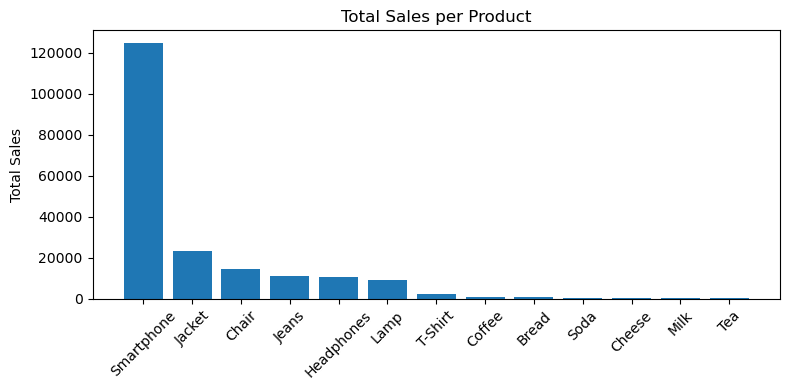

In [3]:
import matplotlib.pyplot as plt

top_sales = products.sort_values("TotalSales", ascending=False)

plt.figure(figsize=(8,4))
plt.bar(top_sales["Product"], top_sales["TotalSales"])
plt.xticks(rotation=45)
plt.ylabel("Total Sales")
plt.title("Total Sales per Product")
plt.tight_layout()
plt.show()


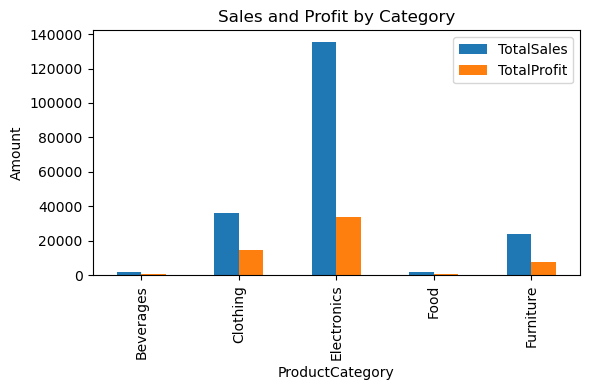

In [4]:
cat_perf = products.groupby("ProductCategory")[["TotalSales","TotalProfit"]].sum()

cat_perf.plot(kind="bar", figsize=(6,4))
plt.ylabel("Amount")
plt.title("Sales and Profit by Category")
plt.tight_layout()
plt.show()


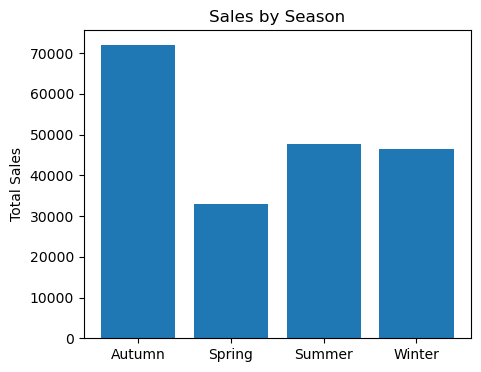

In [5]:
# Merge orders with dim_date to attach Season to each order by OrderDate
orders_with_season = orders.merge(dim_date, on="OrderDate", how="left")

# Aggregate total sales per season using the merged DataFrame
season_sales = orders_with_season.groupby("Season")["TotalSales"].sum().reset_index()

# Plot total sales by season as a bar chart
plt.figure(figsize=(5,4))
plt.bar(season_sales["Season"], season_sales["TotalSales"])
plt.ylabel("Total Sales")
plt.title("Sales by Season")
plt.show()


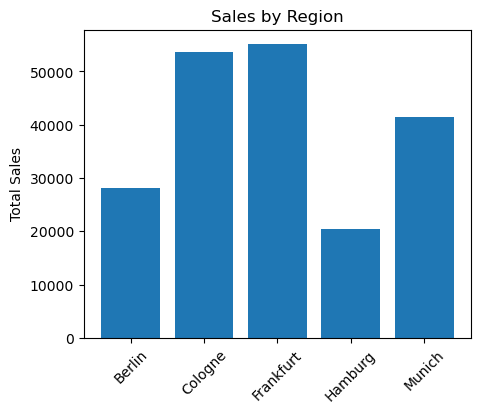

In [6]:
region_sales = orders.groupby("Region")["TotalSales"].sum().reset_index()

plt.figure(figsize=(5,4))
plt.bar(region_sales["Region"], region_sales["TotalSales"])
plt.ylabel("Total Sales")
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.show()


In [7]:
seg_sales = (
    orders
    .groupby("CustomerSegment")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
)
seg_avg_qty = (
    orders
    .groupby("CustomerSegment")["Quantity"]
    .mean()
)

print("\nTotal sales by segment:")
print(seg_sales)

print("\nAverage quantity per order by segment:")
print(seg_avg_qty)



Total sales by segment:
CustomerSegment
Corporate         101579.68
Small Business     49769.85
Consumer           47618.88
Name: TotalSales, dtype: float64

Average quantity per order by segment:
CustomerSegment
Consumer           5.933333
Corporate         29.723404
Small Business    17.490566
Name: Quantity, dtype: float64


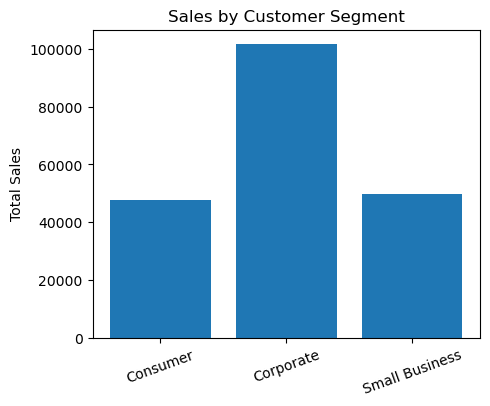

In [8]:
seg_sales = orders.groupby("CustomerSegment")["TotalSales"].sum().reset_index()

plt.figure(figsize=(5,4))
plt.bar(seg_sales["CustomerSegment"], seg_sales["TotalSales"])
plt.ylabel("Total Sales")
plt.title("Sales by Customer Segment")
plt.xticks(rotation=20)
plt.show()


In [9]:
orders_enriched = orders.merge(
    products[["Product","TotalSales","TotalProfit"]],
    on="Product",
    suffixes=("", "_ProductTotal")
)

# which regions sell the most of overall top sold products?
top_prod_names = products.sort_values("TotalSales", ascending=False)["Product"].head(3)
subset = orders_enriched[orders_enriched["Product"].isin(top_prod_names)]

pivot = subset.pivot_table(
    index="Region",
    columns="Product",
    values="TotalSales",
    aggfunc="sum",
    fill_value=0
)
print(pivot)


Product      Chair  Jacket  Smartphone
Region                                
Berlin     3982.00  5952.0     15140.0
Cologne    2873.75  2612.0     36240.0
Frankfurt  2521.75  5872.0     40840.0
Hamburg    2420.00  5992.0      3600.0
Munich     2799.50  2720.0     28800.0
